In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/iMaIrsdyh/KarimahIrsyadiyah_2411533018_ML2526/main/PRAKTIKUM%203/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("Info Dataset:")
df.info()

print("Statistik deskriptif sebelum scaling:")
df.describe().round(2)

Info Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Statistik deskriptif sebelum scaling:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [4]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

print("Fitur yang akan di-scaling:")
print(X.columns.tolist())

Fitur yang akan di-scaling:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


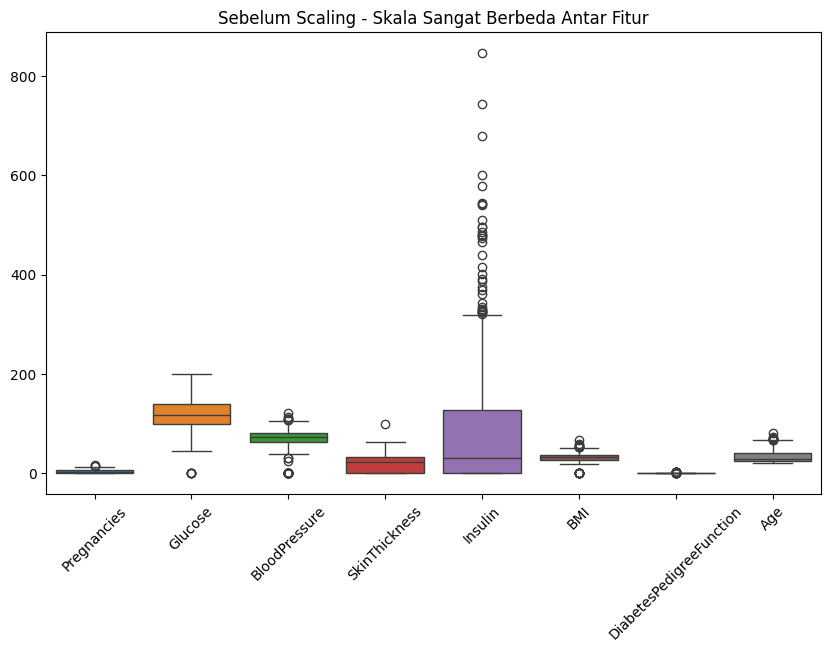

In [5]:
plt.figure(figsize=(10,6))
sns.boxplot(data=X)
plt.title("Sebelum Scaling - Skala Sangat Berbeda Antar Fitur")
plt.xticks(rotation=45)
plt.show()

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("5 baris pertama setelah scaling:")
X_scaled_df.head().round(3)

5 baris pertama setelah scaling:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.640,0.848,0.150,0.907,-0.693,0.204,0.468,1.426
1,-0.845,-1.123,-0.161,0.531,-0.693,-0.684,-0.365,-0.191
2,1.234,1.944,-0.264,-1.288,-0.693,-1.103,0.604,-0.106
3,-0.845,-0.998,-0.161,0.155,0.123,-0.494,-0.921,-1.042
4,-1.142,0.504,-1.505,0.907,0.766,1.410,5.485,-0.020


In [7]:
print("Statistik SEBELUM scaling:")
print(X.describe().round(3))

print("\nStatistik SETELAH scaling:")
print(X_scaled_df.describe().round(3))

Statistik SEBELUM scaling:
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin      BMI  \
count      768.000  768.000        768.000        768.000  768.000  768.000   
mean         3.845  120.895         69.105         20.536   79.799   31.993   
std          3.370   31.973         19.356         15.952  115.244    7.884   
min          0.000    0.000          0.000          0.000    0.000    0.000   
25%          1.000   99.000         62.000          0.000    0.000   27.300   
50%          3.000  117.000         72.000         23.000   30.500   32.000   
75%          6.000  140.250         80.000         32.000  127.250   36.600   
max         17.000  199.000        122.000         99.000  846.000   67.100   

       DiabetesPedigreeFunction      Age  
count                   768.000  768.000  
mean                      0.472   33.241  
std                       0.331   11.760  
min                       0.078   21.000  
25%                       0.244   24.000  
50%

In [8]:
#Split Data
from sklearn.model_selection import train_test_split

X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size =0.2, random_state=42, stratify=y
)

X_train, X_test, _, _ = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (614, 8)
Test size: (154, 8)


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_with_threshold(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"Threshold = {threshold:.2f}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print(f"-"*40)
    
    return {'threshold' : threshold, 'acc' : acc, 'prec' : prec, 'rec' : rec, 'f1' : f1}    

In [10]:
from sklearn.linear_model import LogisticRegression

model_no_scale = LogisticRegression(max_iter=1000)
model_no_scale.fit(X_train, y_train)

proba_no_scale = model_no_scale.predict_proba(X_test)[:, 1]

print("Tanpa Scaling:")
results_no_scale = []
for th in [0.3, 0.4, 0.5, 0.6, 0.7]:
    res = evaluate_with_threshold(y_test, proba_no_scale, th)
    results_no_scale.append(res)

Tanpa Scaling:
Threshold = 0.30
Accuracy : 0.7338
Precision : 0.5867
Recall : 0.8148
F1-score : 0.6822
Confusion Matrix:
 [[69 31]
 [10 44]]
----------------------------------------
Threshold = 0.40
Accuracy : 0.7273
Precision : 0.6071
Recall : 0.6296
F1-score : 0.6182
Confusion Matrix:
 [[78 22]
 [20 34]]
----------------------------------------
Threshold = 0.50
Accuracy : 0.7143
Precision : 0.6087
Recall : 0.5185
F1-score : 0.5600
Confusion Matrix:
 [[82 18]
 [26 28]]
----------------------------------------
Threshold = 0.60
Accuracy : 0.7338
Precision : 0.6857
Recall : 0.4444
F1-score : 0.5393
Confusion Matrix:
 [[89 11]
 [30 24]]
----------------------------------------
Threshold = 0.70
Accuracy : 0.7273
Precision : 0.7143
Recall : 0.3704
F1-score : 0.4878
Confusion Matrix:
 [[92  8]
 [34 20]]
----------------------------------------


In [11]:
model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(X_train_scaled, y_train)

proba_scaled = model_scaled.predict_proba(X_test_scaled)[:, 1]

print("Dengan Scaling:")
results_scaled = []
for th in [0.3, 0.4, 0.5, 0.6, 0.7]:
    res = evaluate_with_threshold(y_test, proba_scaled, th)
    results_scaled.append(res)

Dengan Scaling:
Threshold = 0.30
Accuracy : 0.7403
Precision : 0.5946
Recall : 0.8148
F1-score : 0.6875
Confusion Matrix:
 [[70 30]
 [10 44]]
----------------------------------------
Threshold = 0.40
Accuracy : 0.7338
Precision : 0.6140
Recall : 0.6481
F1-score : 0.6306
Confusion Matrix:
 [[78 22]
 [19 35]]
----------------------------------------
Threshold = 0.50
Accuracy : 0.7143
Precision : 0.6087
Recall : 0.5185
F1-score : 0.5600
Confusion Matrix:
 [[82 18]
 [26 28]]
----------------------------------------
Threshold = 0.60
Accuracy : 0.7338
Precision : 0.6857
Recall : 0.4444
F1-score : 0.5393
Confusion Matrix:
 [[89 11]
 [30 24]]
----------------------------------------
Threshold = 0.70
Accuracy : 0.7273
Precision : 0.7143
Recall : 0.3704
F1-score : 0.4878
Confusion Matrix:
 [[92  8]
 [34 20]]
----------------------------------------


In [12]:
import pandas as pd

df_compare = pd.DataFrame({
    'Threshold': [r['threshold'] for r in results_no_scale],
    'Acc (No Scale)': [r['acc'] for r in results_no_scale],
    'F1 (No Scale)': [r['f1'] for r in results_no_scale],
    'Acc (Scaled)': [r['acc'] for r in results_scaled],
    'F1 (Scaled)': [r['f1'] for r in results_scaled],
})

print("Perbandingan Kinerja:")
print(df_compare.round(4))

# Kalau mau lihat yang mana lebih baik di threshold 0.5
print("\nPada threshold default 0.5:")
print(df_compare[df_compare['Threshold'] == 0.5])

Perbandingan Kinerja:
   Threshold  Acc (No Scale)  F1 (No Scale)  Acc (Scaled)  F1 (Scaled)
0        0.3          0.7338         0.6822        0.7403       0.6875
1        0.4          0.7273         0.6182        0.7338       0.6306
2        0.5          0.7143         0.5600        0.7143       0.5600
3        0.6          0.7338         0.5393        0.7338       0.5393
4        0.7          0.7273         0.4878        0.7273       0.4878

Pada threshold default 0.5:
   Threshold  Acc (No Scale)  F1 (No Scale)  Acc (Scaled)  F1 (Scaled)
2        0.5        0.714286           0.56      0.714286         0.56


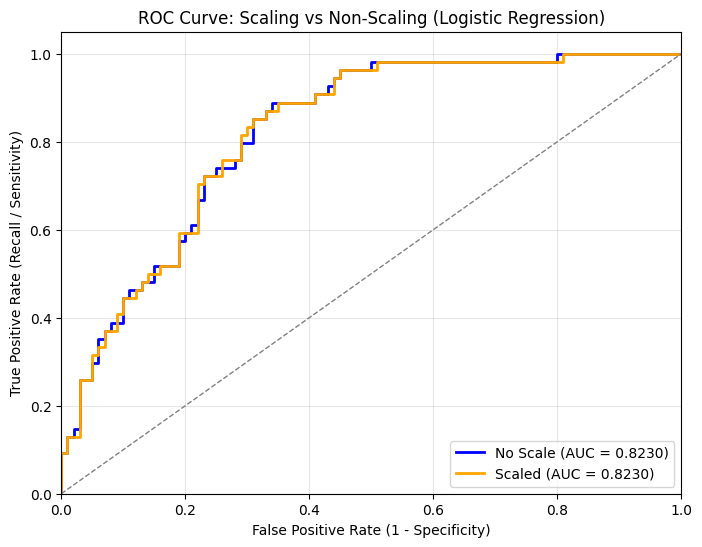

AUC No Scale     : 0.8230
AUC Scaled       : 0.8230


In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Hitung ROC curve dan AUC untuk No Scale
fpr_ns, tpr_ns, thresholds_ns = roc_curve(y_test, proba_no_scale)
roc_auc_ns = auc(fpr_ns, tpr_ns)

# Hitung ROC curve dan AUC untuk Scaled
fpr_s, tpr_s, thresholds_s = roc_curve(y_test, proba_scaled)
roc_auc_s = auc(fpr_s, tpr_s)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_ns, tpr_ns, color='blue', lw=2, label=f'No Scale (AUC = {roc_auc_ns:.4f})')
plt.plot(fpr_s, tpr_s, color='orange', lw=2, label=f'Scaled (AUC = {roc_auc_s:.4f})')

# Garis diagonal (random classifier)
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall / Sensitivity)')
plt.title('ROC Curve: Scaling vs Non-Scaling (Logistic Regression)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Print AUC saja kalau mau cepat lihat
print(f"AUC No Scale     : {roc_auc_ns:.4f}")
print(f"AUC Scaled       : {roc_auc_s:.4f}")